/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [07:34:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


모델 학습 완료!
Global SHAP 값 계산 중... (잠시만 기다려주세요)

[전사 퇴사 위험 핵심 요인 (Global View)]


/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53748 (\N{HANGUL SYLLABLE TOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

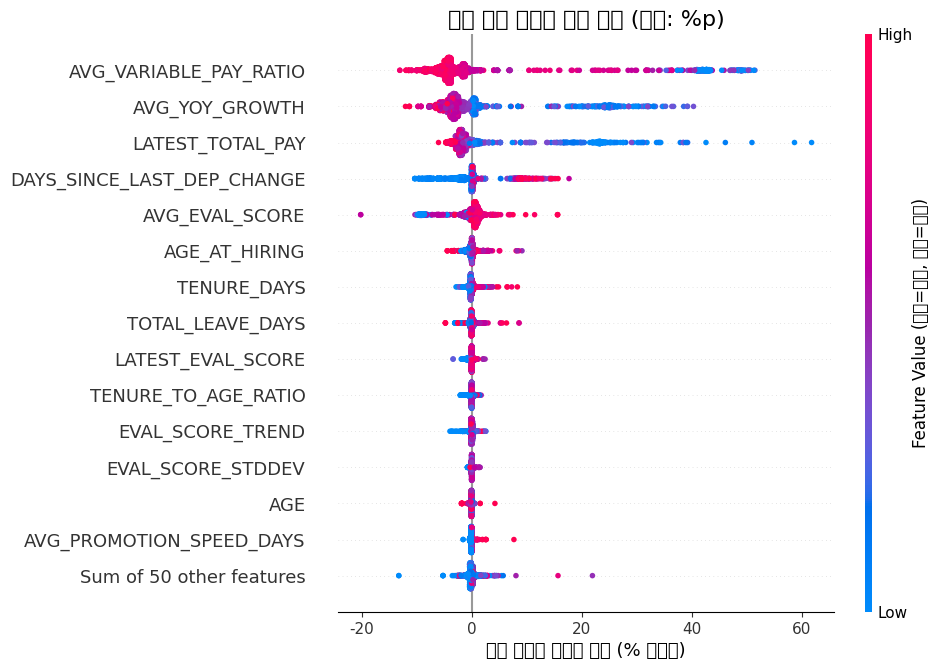

/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

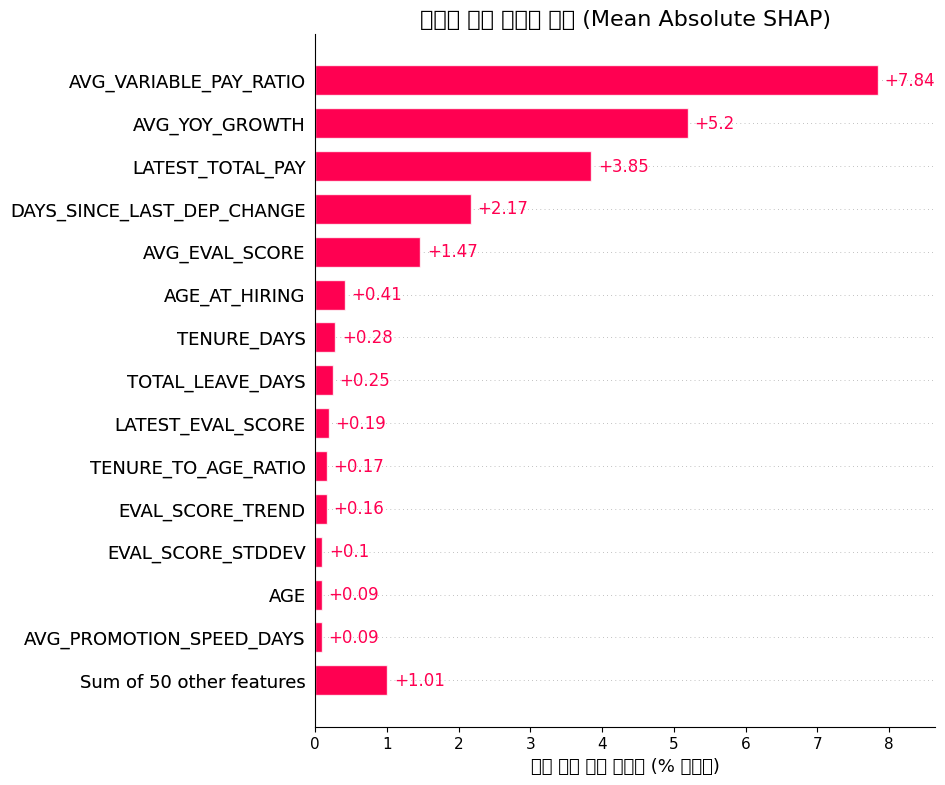


[심층 분석] 가장 영향력이 큰 변수: 'AVG_VARIABLE_PAY_RATIO' 의존성 분석


<Figure size 1000x600 with 0 Axes>

/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

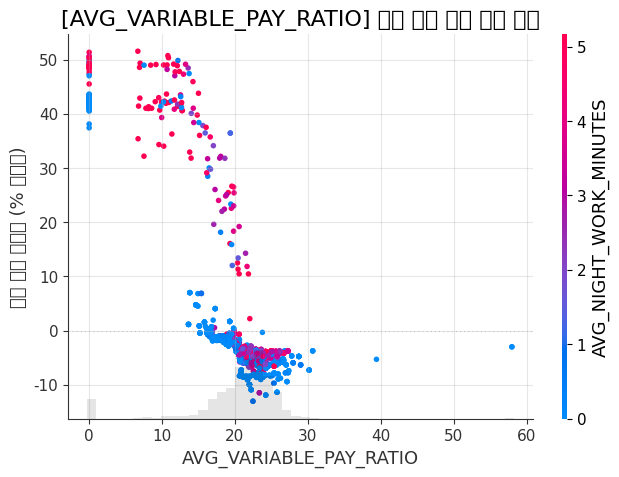

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 1. 한글 폰트 설정 ---
def set_korean_font():
    font_names = [f.name for f in fm.fontManager.ttflist]
    if 'NanumGothic' in font_names:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif 'Malgun Gothic' in font_names:
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif 'AppleGothic' in font_names:
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 데이터 준비 & 전처리 (이전과 동일) ---
master_df_encoded = pd.read_csv('ml_master_table.csv')

# 데이터 타입 정리
for col in master_df_encoded.columns:
    if master_df_encoded[col].dtype == 'object' and col not in ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']:
        master_df_encoded[col] = pd.to_numeric(master_df_encoded[col], errors='coerce')
master_df_encoded.fillna(master_df_encoded.median(numeric_only=True), inplace=True)

# --- 3. 데이터 비율 9:1 조정 ---
df_leavers = master_df_encoded[master_df_encoded['IS_LEAVER'] == 1]
df_active = master_df_encoded[master_df_encoded['IS_LEAVER'] == 0]

n_leavers = len(df_leavers)
n_required_active = n_leavers * 9 

# 재직자 뻥튀기 (Oversampling)
df_active_oversampled = df_active.sample(n=n_required_active, replace=True, random_state=42)
balanced_df = pd.concat([df_leavers, df_active_oversampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

drop_cols = ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']
feature_cols = [col for col in balanced_df.columns if col not in drop_cols]

X_train = balanced_df[feature_cols].astype(float)
y_train = balanced_df['IS_LEAVER'].astype(float)

# --- 4. 모델 학습 (가중치 10만 적용) ---
weight_ratio = 100000.0
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=6,
    learning_rate=0.1, 
    scale_pos_weight=weight_ratio,
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
model.fit(X_train, y_train)
print("모델 학습 완료!")

# --- 5. Global SHAP 분석 ---
X_sample = X_train.sample(n=min(2000, len(X_train)), random_state=42)
background_data = shap.sample(X_train, 100)

explainer = shap.TreeExplainer(
    model, 
    data=background_data, 
    feature_perturbation="interventional",
    model_output="probability"
)

print("Global SHAP 값 계산 중... (잠시만 기다려주세요)")
shap_values_global = explainer(X_sample)

# --- 6. 단위 변환 (확률 -> 퍼센트) ---
shap_values_global.values = shap_values_global.values * 100
shap_values_global.base_values = shap_values_global.base_values * 100

# --- 7. 시각화 (Beeswarm Plot) ---
print("\n[전사 퇴사 위험 핵심 요인 (Global View)]")
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values_global, 
    max_display=15,    
    show=False,
    color_bar_label="Feature Value (빨강=높음, 파랑=낮음)"
)
plt.title("전사 퇴사 위험도 영향 요인 (단위: %p)", fontsize=16)
plt.xlabel("퇴사 확률에 미치는 영향 (% 포인트)")
plt.show()

# --- 8. (옵션) 단순 중요도 Bar Plot ---
plt.figure(figsize=(10, 6))
shap.plots.bar(
    shap_values_global, 
    max_display=15, 
    show=False
)
plt.title("요인별 평균 영향력 크기 (Mean Absolute SHAP)", fontsize=16)
plt.xlabel("평균 퇴사 확률 변동폭 (% 포인트)")
plt.show()

# =============================================================================
# 🎨 [추가] SHAP Dependence Plot (Partial Dependence Plot 대체)
# =============================================================================
# 가장 중요한 변수(Top 1)를 자동으로 찾아서 상세 분석 그래프를 그립니다.
# (Y축: 해당 변수가 퇴사 확률을 얼마나 높이고 낮췄는지 보여줌)

# 1. 가장 중요한 변수 이름 찾기
# (평균 절대 SHAP 값이 가장 큰 변수)
top_feature_idx = np.abs(shap_values_global.values).mean(0).argmax()
top_feature_name = shap_values_global.feature_names[top_feature_idx]

print(f"\n[심층 분석] 가장 영향력이 큰 변수: '{top_feature_name}' 의존성 분석")

# 2. Dependence Plot 그리기
# color=shap_values_global은 자동으로 상호작용(Interaction)이 강한 다른 변수로 색상을 입혀줍니다.
plt.figure(figsize=(10, 6))
shap.plots.scatter(
    shap_values_global[:, top_feature_name], 
    color=shap_values_global, 
    show=False
)

plt.title(f"[{top_feature_name}] 값에 따른 퇴사 확률 변화", fontsize=16)
plt.ylabel("퇴사 확률 영향도 (% 포인트)")
plt.grid(True, alpha=0.3)
plt.show()

📊 그래프 해석 가이드: 3가지 포인트만 기억하세요!
1. 무엇이 가장 중요한가요? (Y축)

맨 위에 있는 항목일수록 퇴사 여부를 결정짓는 가장 강력한 요인입니다.

2. 색깔은 무엇을 의미하나요? (Color)

🔴 빨간색: 수치가 높음 (High) (예: 야근 많음, 고연차)

🔵 파란색: 수치가 낮음 (Low) (예: 야근 적음, 저연차)

3. 오른쪽인가요, 왼쪽인가요? (X축)

👉 오른쪽 (+): 퇴사 확률을 높임 (위험 ⚠️)

👈 왼쪽 (-): 퇴사 확률을 낮춤 (안전 ✅)

예시: **"야근 시간"**이 **빨간색(🔴)**인데 **오른쪽(👉)**에 있다면? *"야근을 많이 할수록 퇴사 위험이 높아진다"*는 뜻입니다.

/usr/local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [07:34:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



[Global View 1] 전사 퇴사 위험 핵심 요인


/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53748 (\N{HANGUL SYLLABLE TOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

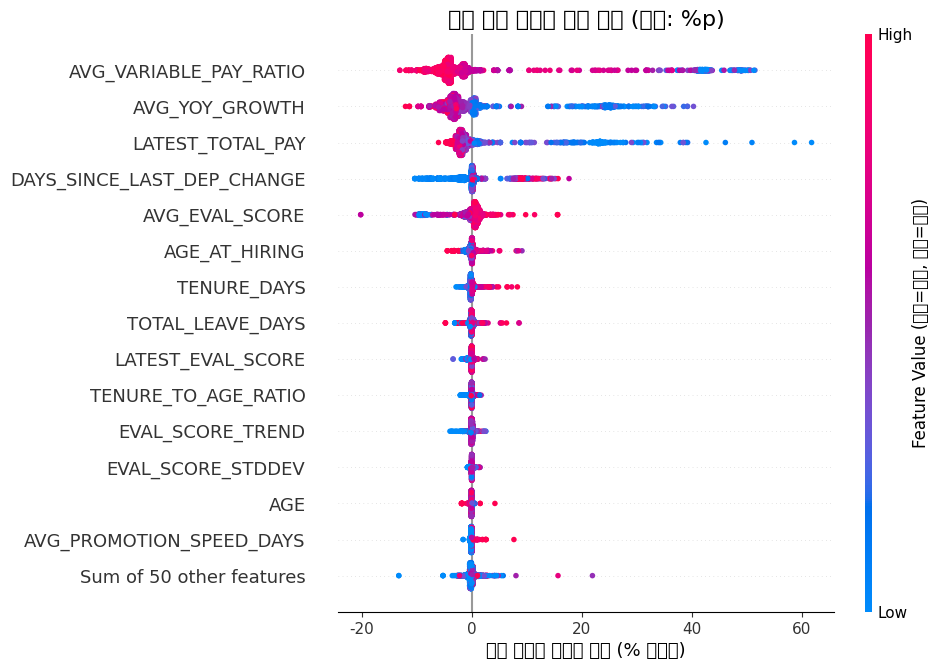


[Global View 2] 심층 분석: AVG_VARIABLE_PAY_RATIO


<Figure size 1000x600 with 0 Axes>

/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

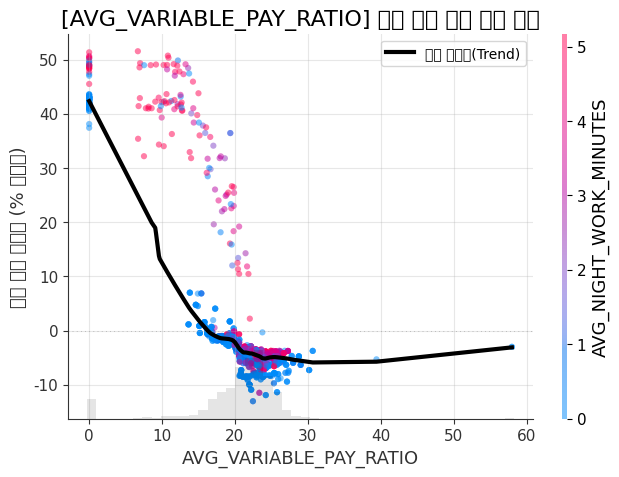

In [2]:
# 추세선을 그리기 위한 라이브러리 (없으면 pip install statsmodels)
import statsmodels.api as sm

# --- 1. 한글 폰트 설정 ---
def set_korean_font():
    font_names = [f.name for f in fm.fontManager.ttflist]
    if 'NanumGothic' in font_names:
        plt.rcParams['font.family'] = 'NanumGothic'
    elif 'Malgun Gothic' in font_names:
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif 'AppleGothic' in font_names:
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 데이터 준비 & 전처리 ---
master_df_encoded = pd.read_csv('ml_master_table.csv')

for col in master_df_encoded.columns:
    if master_df_encoded[col].dtype == 'object' and col not in ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']:
        master_df_encoded[col] = pd.to_numeric(master_df_encoded[col], errors='coerce')
master_df_encoded.fillna(master_df_encoded.median(numeric_only=True), inplace=True)

# --- 3. 데이터 비율 9:1 조정 ---
df_leavers = master_df_encoded[master_df_encoded['IS_LEAVER'] == 1]
df_active = master_df_encoded[master_df_encoded['IS_LEAVER'] == 0]
n_required_active = len(df_leavers) * 9 
df_active_oversampled = df_active.sample(n=n_required_active, replace=True, random_state=42)
balanced_df = pd.concat([df_leavers, df_active_oversampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

drop_cols = ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']
feature_cols = [col for col in balanced_df.columns if col not in drop_cols]
X_train = balanced_df[feature_cols].astype(float)
y_train = balanced_df['IS_LEAVER'].astype(float)

# --- 4. 모델 학습 (가중치 10만) ---
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, 
    scale_pos_weight=100000.0, random_state=42, 
    use_label_encoder=False, eval_metric='logloss'
)
model.fit(X_train, y_train)

# --- 5. Global SHAP 값 계산 ---
# 분석용 샘플 (속도를 위해 2000개)
X_sample = X_train.sample(n=min(2000, len(X_train)), random_state=42)
background = shap.sample(X_train, 100)

explainer = shap.TreeExplainer(model, data=background, feature_perturbation="interventional", model_output="probability")
shap_values = explainer(X_sample)

# % 단위 변환
shap_values.values = shap_values.values * 100
shap_values.base_values = shap_values.base_values * 100

# =============================================================================
# 🎨 1. Beeswarm Plot (전체 요약)
# =============================================================================
print("\n[Global View 1] 전사 퇴사 위험 핵심 요인")
plt.figure(figsize=(12, 8))
shap.plots.beeswarm(
    shap_values, 
    max_display=15,
    show=False,
    color_bar_label="Feature Value (빨강=높음, 파랑=낮음)"
)
plt.title("전사 퇴사 위험도 영향 요인 (단위: %p)", fontsize=16)
plt.xlabel("퇴사 확률에 미치는 영향 (% 포인트)")
plt.show()

# =============================================================================
# 🎨 2. Enhanced Scatter Plot (상세 분석) - 추세선 추가
# =============================================================================


# 가장 중요한 변수 자동 선택
top_feature_idx = np.abs(shap_values.values).mean(0).argmax()
top_feature_name = shap_values.feature_names[top_feature_idx]

print(f"\n[Global View 2] 심층 분석: {top_feature_name}")

# 데이터 추출
x_data = X_sample[top_feature_name].values
y_shap = shap_values[:, top_feature_name].values

plt.figure(figsize=(10, 6))

# (1) 기본 SHAP Scatter (데이터 분포 확인용)
# color=shap_values를 쓰면 상호작용 변수에 따라 색이 입혀짐
shap.plots.scatter(
    shap_values[:, top_feature_name], 
    color=shap_values, 
    show=False,
    dot_size=20,
    alpha=0.5
)

# (2) 추세선 추가 (Lowess Smoothing) - EBM의 선 그래프 느낌 내기
# statsmodels의 lowess를 사용하여 부드러운 곡선 그리기
lowess = sm.nonparametric.lowess
trend = lowess(y_shap, x_data, frac=0.2) # frac은 곡선의 부드러움 정도 (0~1)

# 추세선 그리기 (검은색 실선)
plt.plot(trend[:, 0], trend[:, 1], color='black', linewidth=3, label='평균 영향도(Trend)')

plt.title(f"[{top_feature_name}] 값에 따른 퇴사 확률 변화", fontsize=16)
plt.ylabel("퇴사 확률 영향도 (% 포인트)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()